In [6]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
import os

In [28]:
csv_path = "../ev_trips_datasets/TripA01.csv"

df = pd.read_csv(csv_path,encoding="latin1",sep=';')
for col in df.columns:
    print(repr(col))
df.head()


'Time [s]'
'Velocity [km/h]'
'Elevation [m]'
'Throttle [%]'
'Motor Torque [Nm]'
'Longitudinal Acceleration [m/s^2]'
'Regenerative Braking Signal '
'Battery Voltage [V]'
'Battery Current [A]'
'Battery Temperature [°C]'
'max. Battery Temperature [°C]'
'SoC [%]'
'displayed SoC [%]'
'min. SoC [%]'
'max. SoC [%)'
'Heating Power CAN [kW]'
'Heating Power LIN [W]'
'Requested Heating Power [W]'
'AirCon Power [kW]'
'Heater Signal'
'Heater Voltage [V]'
'Heater Current [A]'
'Ambient Temperature [°C]'
'Coolant Temperature Heatercore [°C]'
'Requested Coolant Temperature [°C]'
'Coolant Temperature Inlet [°C]'
'Heat Exchanger Temperature [°C]'
'Cabin Temperature Sensor [°C]'


,Time [s],Velocity [km/h],Elevation [m],Throttle [%],Motor Torque [Nm],Longitudinal Acceleration [m/s^2],Regenerative Braking Signal,Battery Voltage [V],Battery Current [A],Battery Temperature [°C],max. Battery Temperature [°C],SoC [%],displayed SoC [%],min. SoC [%],max. SoC [%),Heating Power CAN [kW],Heating Power LIN [W],Requested Heating Power [W],AirCon Power [kW],Heater Signal,Heater Voltage [V],Heater Current [A],Ambient Temperature [°C],Coolant Temperature Heatercore [°C],Requested Coolant Temperature [°C],Coolant Temperature Inlet [°C],Heat Exchanger Temperature [°C],Cabin Temperature Sensor [°C]
0,0.0,0.0,574.0,0.0,0.0,-0.03,0.0,391.4,-2.20,21.0,22.0,86.9,100.0,8,90,0.0,0,85,0.4,1,0,0,25.5,0,0,0,30.5,24.5
1,0.1,0.0,574.0,0.0,0.0,0.00,0.0,391.4,-2.21,21.0,22.0,86.9,100.0,8,90,0.0,0,85,0.4,1,0,0,25.5,0,0,0,30.5,24.5
2,0.2,0.0,574.0,0.0,0.0,-0.01,0.0,391.4,-2.26,21.0,22.0,86.9,100.0,8,90,0.0,0,85,0.4,1,0,0,25.5,0,0,0,30.5,24.5
3,0.3,0.0,574.0,0.0,0.0,-0.03,0.0,391.4,-2.30,21.0,22.0,86.9,100.0,8,90,0.0,0,85,0.4,1,0,0,25.5,0,0,0,30.5,24.5
4,0.4,0.0,574.0,0.0,0.0,-0.03,0.0,391.4,-2.30,21.0,22.0,86.9,100.0,8,90,0.0,0,85,0.4,1,0,0,25.5,0,0,0,30.5,24.5


# Visulization of data

In [42]:

import matplotlib.pyplot as plt

viz_csv_path = "../ev_trips_datasets/TripA01.csv"

viz_df = pd.read_csv(
    viz_csv_path,
    encoding="latin1",
    sep=";"
)

viz_df.columns = viz_df.columns.str.strip()

viz_df = viz_df[
    [
        'Time [s]',
        'Velocity [km/h]',
        'Battery Current [A]',
        'Battery Voltage [V]',
        'Battery Temperature [°C]',
        'SoC [%]'
    ]
].dropna().reset_index(drop=True)

viz_df.head()


,Time [s],Velocity [km/h],Battery Current [A],Battery Voltage [V],Battery Temperature [°C],SoC [%]
0,0.0,0.0,-2.20,391.4,21.0,86.9
1,0.1,0.0,-2.21,391.4,21.0,86.9
2,0.2,0.0,-2.26,391.4,21.0,86.9
3,0.3,0.0,-2.30,391.4,21.0,86.9
4,0.4,0.0,-2.30,391.4,21.0,86.9


## 🟩 SOC vs Time (core plot)

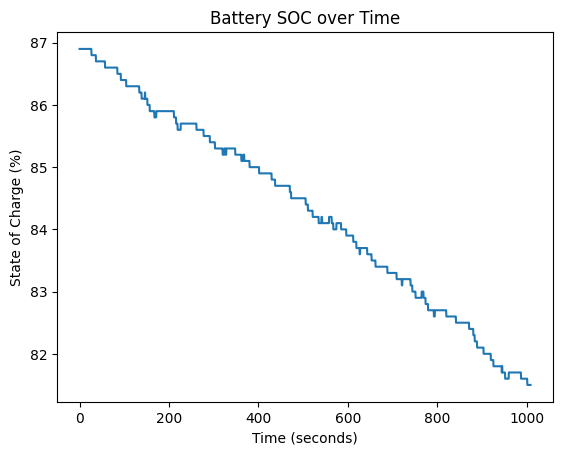

In [43]:
plt.figure()
plt.plot(viz_df['Time [s]'], viz_df['SoC [%]'])
plt.xlabel("Time (seconds)")
plt.ylabel("State of Charge (%)")
plt.title("Battery SOC over Time")
plt.show()


## 🟩 Speed vs Time

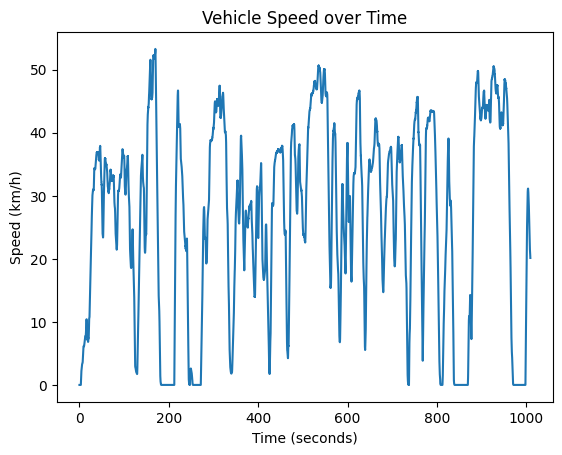

In [44]:
plt.figure()
plt.plot(viz_df['Time [s]'], viz_df['Velocity [km/h]'])
plt.xlabel("Time (seconds)")
plt.ylabel("Speed (km/h)")
plt.title("Vehicle Speed over Time")
plt.show()


## 🟩 SOC + Speed overlay (intuition builder)

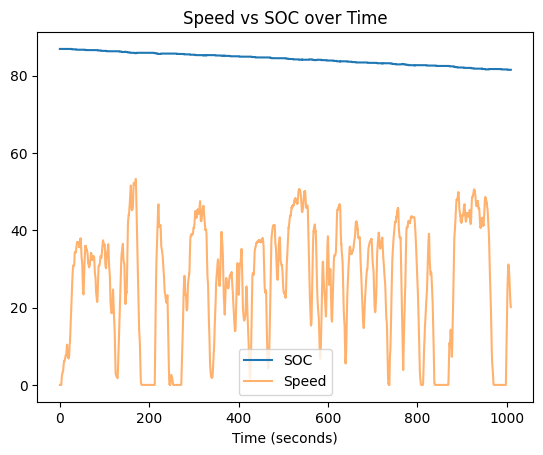

In [46]:
plt.figure()
plt.plot(viz_df['Time [s]'], viz_df['SoC [%]'], label="SOC")
plt.plot(
    viz_df['Time [s]'],
    viz_df['Velocity [km/h]'],
    label="Speed",
    alpha=0.6
)
plt.xlabel("Time (seconds)")
plt.legend()
plt.title("Speed vs SOC over Time")
plt.show()


## 🟩 Battery current vs time

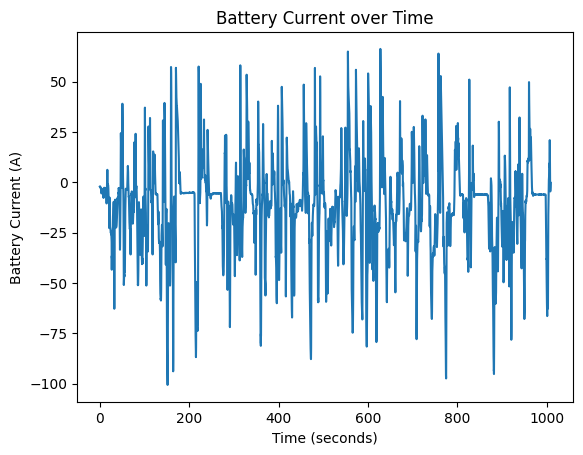

In [47]:
plt.figure()
plt.plot(viz_df['Time [s]'], viz_df['Battery Current [A]'])
plt.xlabel("Time (seconds)")
plt.ylabel("Battery Current (A)")
plt.title("Battery Current over Time")
plt.show()


## 🟩 LSTM window perspective (VERY IMPORTANT)

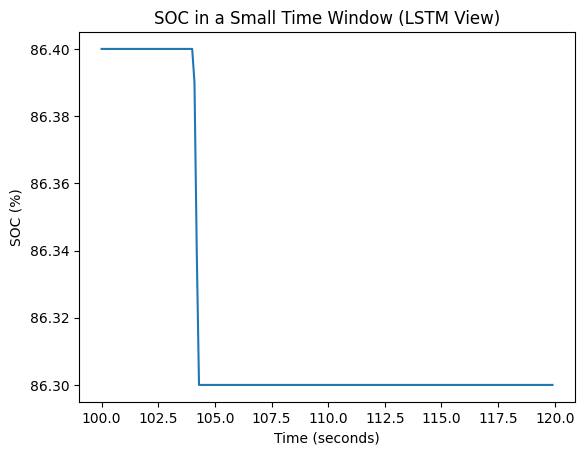

In [48]:
viz_start = 1000
viz_window = 200

plt.figure()
plt.plot(
    viz_df['Time [s]'][viz_start:viz_start + viz_window],
    viz_df['SoC [%]'][viz_start:viz_start + viz_window]
)
plt.xlabel("Time (seconds)")
plt.ylabel("SOC (%)")
plt.title("SOC in a Small Time Window (LSTM View)")
plt.show()


# LSTM building and pre-processing

In [28]:
def process_single_trip(csv_path, window_size=20):
    df = pd.read_csv(csv_path, encoding='latin1', sep=';')
    df.columns = df.columns.str.strip()

    required_cols = [
        'Velocity [km/h]',
        'Battery Current [A]',
        'Battery Voltage [V]',
        'Battery Temperature [°C]',
        'SoC [%]'
    ]

    # 🔒 Check if ALL required columns exist
    for col in required_cols:
        if col not in df.columns:
            # Skip this file safely
            print(f"Skipping {csv_path} (missing {col})")
            return np.array([]), np.array([])

    df = df[required_cols]
    df = df.dropna().reset_index(drop=True)

    # If not enough rows for one window
    if len(df) <= window_size:
        return np.array([]), np.array([])

    scaler = MinMaxScaler()
    scaled_data = scaler.fit_transform(df.values)

    X, y = [], []
    for i in range(len(scaled_data) - window_size):
        X.append(scaled_data[i:i + window_size, :])
        y.append(scaled_data[i + window_size, -1])

    return np.array(X), np.array(y).reshape(-1, 1)


In [8]:
trip_folder = "../ev_trips_datasets"
all_X,all_y=[],[]
for file in os.listdir(trip_folder):
    if file.endswith(".csv"):
        path=os.path.join(trip_folder,file)
        X_trip,y_trip=process_single_trip(path)
        if len(X_trip) > 0:
            all_X.append(X_trip)
            all_y.append(y_trip)
X=np.concatenate(all_X,axis=0)
y=np.concatenate(all_y,axis=0)

print("Final X shape:", X.shape)
print("Final y shape:", y.shape)

Skipping ../ev_trips_datasets\TripB38.csv (missing Velocity [km/h])
Final X shape: (1046191, 20, 5)
Final y shape: (1046191, 1)


In [9]:
print("X dtype:", X.dtype)
print("y dtype:", y.dtype)

print("\nOne sample window shape:", X[0].shape)
print("One target value:", y[0])

print("\nSOC min/max in y:")
print(y.min(), y.max())


X dtype: float64
y dtype: float64

One sample window shape: (20, 5)
One target value: [1.]

SOC min/max in y:
0.0 1.0000000000000018


In [10]:
display(X)

array([[[0.        , 0.59010304, 0.78149466, 0.        , 1.        ],
        [0.        , 0.59004313, 0.78149466, 0.        , 1.        ],
        [0.        , 0.58974359, 0.78149466, 0.        , 1.        ],
        ...,
        [0.        , 0.58632878, 0.77437722, 0.        , 1.        ],
        [0.        , 0.58572969, 0.77437722, 0.        , 1.        ],
        [0.        , 0.5851306 , 0.77437722, 0.        , 1.        ]],

       [[0.        , 0.59004313, 0.78149466, 0.        , 1.        ],
        [0.        , 0.58974359, 0.78149466, 0.        , 1.        ],
        [0.        , 0.58950395, 0.78149466, 0.        , 1.        ],
        ...,
        [0.        , 0.58572969, 0.77437722, 0.        , 1.        ],
        [0.        , 0.5851306 , 0.77437722, 0.        , 1.        ],
        [0.        , 0.58453151, 0.77437722, 0.        , 1.        ]],

       [[0.        , 0.58974359, 0.78149466, 0.        , 1.        ],
        [0.        , 0.58950395, 0.78149466, 0.        , 1. 

In [11]:
X=X.astype("float32")
y=y.astype("float32")
print(X.dtype, y.dtype)


float32 float32


In [12]:
split_idx = int(0.8 * len(X))
print(split_idx)


836952


In [13]:
X_train=X[:split_idx]
y_train=y[:split_idx]

X_val=X[split_idx:]
y_val=y[split_idx:]

print("Train:", X_train.shape, y_train.shape)
print("Val:", X_val.shape, y_val.shape)

Train: (836952, 20, 5) (836952, 1)
Val: (209239, 20, 5) (209239, 1)


In [14]:
print("Train SOC min/max:", y_train.min(), y_train.max())
print("Val SOC min/max:", y_val.min(), y_val.max())

print("Sample train target:", y_train[0])
print("Sample val target:", y_val[0])


Train SOC min/max: 0.0 1.0
Val SOC min/max: 0.0 1.0
Sample train target: [1.]
Sample val target: [0.18309858]


In [15]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM,Dense

In [16]:
model=Sequential()

In [17]:
model.add(
    LSTM(
        units=64,
        input_shape=(20,5)
    )
)

C:\Users\andeg\AppData\Roaming\Python\Python310\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [18]:
model.add(Dense(1))

In [19]:
model.compile(
    optimizer="adam",
    loss="mse"
)

In [20]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                          │ (None, 64)                  │          17,920 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 1)                   │              65 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 17,985 (70.25 KB)

 Trainable params: 17,985 (70.25 KB)

 Non-trainable params: 0 (0.00 B)

In [21]:
history=model.fit(
    X_train,
    y_train,
    validation_data=(X_val,y_val),
    epochs=5,
    batch_size=256
)
                 

Epoch 1/5
3270/3270 ━━━━━━━━━━━━━━━━━━━━ 111s 33ms/step - loss: 0.0044 - val_loss: 4.0831e-06
Epoch 2/5
3270/3270 ━━━━━━━━━━━━━━━━━━━━ 147s 35ms/step - loss: 7.1258e-06 - val_loss: 1.1113e-05
Epoch 3/5
3270/3270 ━━━━━━━━━━━━━━━━━━━━ 111s 34ms/step - loss: 7.1075e-06 - val_loss: 5.0424e-06
Epoch 4/5
3270/3270 ━━━━━━━━━━━━━━━━━━━━ 138s 33ms/step - loss: 5.8331e-06 - val_loss: 3.4405e-06
Epoch 5/5
3270/3270 ━━━━━━━━━━━━━━━━━━━━ 107s 33ms/step - loss: 4.0834e-06 - val_loss: 7.3151e-06


In [22]:
# Predict SOC on validation set
y_val_pred = model.predict(X_val)


6539/6539 ━━━━━━━━━━━━━━━━━━━━ 32s 5ms/step


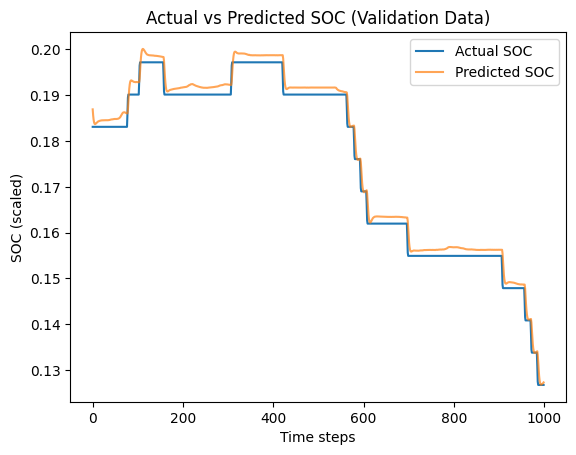

In [23]:
import matplotlib.pyplot as plt

# Take a small slice for visualization
viz_len = 1000  # first 1000 validation points

plt.figure()
plt.plot(y_val[:viz_len], label="Actual SOC")
plt.plot(y_val_pred[:viz_len], label="Predicted SOC", alpha=0.7)
plt.xlabel("Time steps")
plt.ylabel("SOC (scaled)")
plt.title("Actual vs Predicted SOC (Validation Data)")
plt.legend()
plt.show()


In [26]:
model.save("ev_soc_lstm_model.keras")


# Scalar creation

In [33]:
trip_folder = "../ev_trips_datasets"

feature_cols = [
    'Velocity [km/h]',
    'Battery Current [A]',
    'Battery Voltage [V]',
    'Battery Temperature [°C]',
    'SoC [%]'
]

dfs = []

for file in os.listdir(trip_folder):
    if file.endswith(".csv"):
        path = os.path.join(trip_folder, file)
        temp_df = pd.read_csv(path, encoding="latin1", sep=";")

        # keep only required columns
        if all(col in temp_df.columns for col in feature_cols):
            dfs.append(temp_df[feature_cols])

# combine all trips
df = pd.concat(dfs, ignore_index=True)

print(df.shape)


(1078364, 5)


In [34]:
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(df)

print("Scaler fitted")

Scaler fitted


In [35]:
import joblib

joblib.dump(scaler, "ev_feature_scaler.pkl")
print("Scaler saved successfully")


Scaler saved successfully


# Checking the saved models

In [36]:
loaded_scaler = joblib.load("ev_feature_scaler.pkl")
print(type(loaded_scaler))


<class 'sklearn.preprocessing._data.MinMaxScaler'>


In [37]:
from tensorflow.keras.models import load_model
import joblib

test_model = load_model("ev_soc_lstm_model.keras")
test_scaler = joblib.load("ev_feature_scaler.pkl")

print(type(test_model))
print(type(test_scaler))


<class 'keras.src.models.sequential.Sequential'>
<class 'sklearn.preprocessing._data.MinMaxScaler'>


C:\Users\andeg\AppData\Roaming\Python\Python310\site-packages\keras\src\saving\saving_lib.py:802: UserWarning: Skipping variable loading for optimizer 'rmsprop', because it has 7 variables whereas the saved optimizer has 12 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))
